<a href="https://colab.research.google.com/github/ustavoteles/supermercado_analise_dados/blob/main/supermercado_analisedados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados de Vendas

Escolhi o dataset de vendas de uma rede de supermercado porque ele contém dados que são típicos de um ambiente de vendas e que representam o comportamento dos consumidores. O mercado de supermercados é uma indústria relevante, e esse tipo de análise é aplicável ao setor comercial. Além disso, o dataset oferece um número razoável de variáveis que são úteis para análise, como:

  - Preço Unitário e Quantidade: Variáveis essenciais para cálculos de receita e lucro.
  - Total: Resultado das vendas, que é o principal objetivo da análise.
  - Gênero, Tipo de Cliente e Pagamento: Variáveis categóricas que permitem entender o comportamento dos consumidores.

Esse dataset também simula um ambiente real de mercado de trabalho, o que o torna interessante e valioso para práticas de análise de dados e aprendizado de máquina. Além disso, ele oferece diversas variáveis que podem ser utilizadas para análise exploratória, identificação de padrões e possíveis previsões de vendas, o que é altamente aplicável para um profissional que deseja se aprofundar no mercado de análise de dados.

Link do Dataset: https://www.kaggle.com/datasets/aungpyaeap/supermarket-sales?resource=download

## 1. Importação das Bibliotecas

Nesta seção, importamos as bibliotecas Python que serão utilizadas para a análise de dados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import random

df = pd.read_csv("/content/mercado-vendas.csv")
print (df)

    ID da Fatura Filial     Cidade Tipo de Cliente  Gênero  \
0    750-67-8428      A     Yangon          Member  Female   
1    226-31-3081      C  Naypyitaw          Normal  Female   
2    631-41-3108      A     Yangon          Normal    Male   
3    123-19-1176      A     Yangon          Member    Male   
4    373-73-7910      A     Yangon          Normal    Male   
..           ...    ...        ...             ...     ...   
995  233-67-5758      C  Naypyitaw          Normal    Male   
996  303-96-2227      B   Mandalay          Normal  Female   
997  727-02-1313      A     Yangon          Member    Male   
998  347-56-2442      A     Yangon          Normal    Male   
999  849-09-3807      A     Yangon          Member  Female   

           Linha de Produto  Preço Unitário  Quantidade  Imposto 5%  \
0         Health and beauty           74.69           7     26.1415   
1    Electronic accessories           15.28           5      3.8200   
2        Home and lifestyle           46.3

#Análise Exploratória

In [ ]:
print(df.shape)  # Verificando a estrutura do DataSet
print(df.head())
print(df.info())
print(df.describe())

(1000, 17)
  ID da Fatura Filial     Cidade Tipo de Cliente  Gênero  \
0  750-67-8428      A     Yangon          Member  Female   
1  226-31-3081      C  Naypyitaw          Normal  Female   
2  631-41-3108      A     Yangon          Normal    Male   
3  123-19-1176      A     Yangon          Member    Male   
4  373-73-7910      A     Yangon          Normal    Male   

         Linha de Produto  Preço Unitário  Quantidade  Imposto 5%     Total  \
0       Health and beauty           74.69           7     26.1415  548.9715   
1  Electronic accessories           15.28           5      3.8200   80.2200   
2      Home and lifestyle           46.33           7     16.2155  340.5255   
3       Health and beauty           58.22           8     23.2880  489.0480   
4       Sports and travel           86.31           7     30.2085  634.3785   

        Data   Hora    Pagamento  Custo de Mercadorias Vendidas  \
0   1/5/2019  13:08      Ewallet                         522.83   
1   3/8/2019  10:29

In [ ]:
print(df.isnull().sum()) #Verificando se contém dados faltantes

ID da Fatura                      0
 Filial                           0
 Cidade                           0
 Tipo de Cliente                  0
 Gênero                           0
 Linha de Produto                 0
 Preço Unitário                   0
 Quantidade                       0
 Imposto 5%                       0
 Total                            0
 Data                             0
 Hora                             0
 Pagamento                        0
 Custo de Mercadorias Vendidas    0
 Percentual de Margem Bruta       0
 Renda Bruta                      0
 Avaliação                        0
dtype: int64


##Média de Vendas com base nas **Linhas de Produto**


In [ ]:
print("Estatisticas Linha de Produtos com base no Total")
print(df.groupby(by=['Linha de Produto'])['Total'].describe().transpose())

Estatisticas Linha de Produtos com base no Total
Linha de Produto  Electronic accessories  Fashion accessories  \
count                         170.000000           178.000000   
mean                          319.632538           305.089298   
std                           245.945626           243.564130   
min                            26.722500            12.694500   
25%                           118.503000           106.155000   
50%                           241.216500           211.648500   
75%                           475.823250           442.690500   
max                           942.448500          1042.650000   

Linha de Produto  Food and beverages  Health and beauty  Home and lifestyle  \
count                     174.000000         152.000000          160.000000   
mean                      322.671517         323.643020          336.636956   
std                       247.157780         237.538815          254.600671   
min                        22.659000          18.

##Totalizando as vendas por Cidade e média de vendas por cidade

In [ ]:
vendas_por_cidade = df.groupby(by=['Cidade'])['Total'].sum()
media_por_cidade = df.groupby(by=['Cidade'])['Total'].mean()
print(vendas_por_cidade)

vendas_por_cidade.describe()

Cidade
Mandalay     106197.6720
Naypyitaw    110568.7065
Yangon       106200.3705
Name: Total, dtype: float64


,Total
count,3.000000
mean,107655.583000
std,2522.839316
min,106197.672000
25%,106199.021250
50%,106200.370500
75%,108384.538500
max,110568.706500


##Totalizando as vendas por Linha de Produtos

In [ ]:
vendas_por_linha = df.groupby(by=['Linha de Produto'])['Total'].sum()
print(vendas_por_linha)

vendas_por_linha.describe()

Linha de Produto
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64


,Total
count,6.000000
mean,53827.791500
std,2408.728819
min,49193.739000
25%,53972.908500
50%,54321.713250
75%,54926.502750
max,56144.844000


##Totalizando a forma de pagamento por cidade

In [ ]:
forma_de_pagamento_cidade = df.groupby(by=['Cidade', 'Pagamento'])['Total'].sum()
print(forma_de_pagamento_cidade)

Cidade     Pagamento  
Mandalay   Cash           35339.4615
           Credit card    37344.8565
           Ewallet        33513.3540
Naypyitaw  Cash           43085.8575
           Credit card    30327.4650
           Ewallet        37155.3840
Yangon     Cash           33781.2510
           Credit card    33094.7505
           Ewallet        39324.3690
Name: Total, dtype: float64


##Total de vendas por cidade




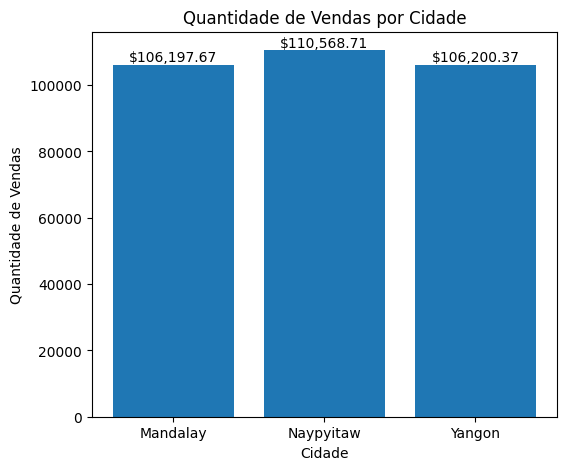

In [ ]:
plt.figure(figsize=(6,5))

for i, valor in enumerate(vendas_por_cidade):
    plt.text(i, valor + 5, f'${valor:,.2f}', ha='center', va='bottom')

plt.bar(vendas_por_cidade.index, vendas_por_cidade)
plt.xlabel('Cidade')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas por Cidade')
plt.show()

É possível analisar que as cidades possuem quantidades prróximas porém, Naypitaw possui mais vendas.

##Média de Vendas Por Cidade

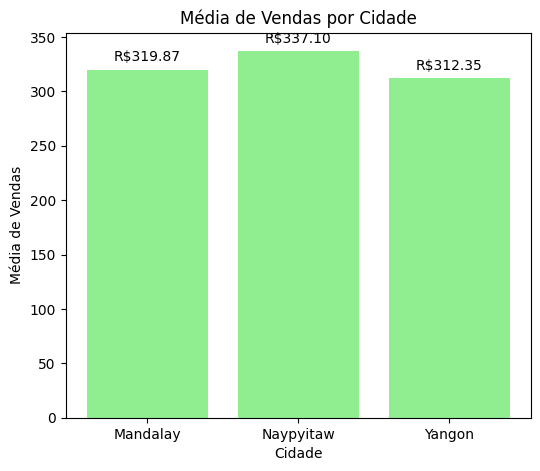

In [ ]:
plt.figure(figsize=(6, 5))

plt.bar(media_por_cidade.index, media_por_cidade, color='lightgreen')

for i, valor in enumerate(media_por_cidade):
    plt.text(i, valor + 5, f'R${valor:,.2f}', ha='center', va='bottom')  # Formatação monetária

plt.xlabel('Cidade')
plt.ylabel('Média de Vendas')
plt.title('Média de Vendas por Cidade')

plt.show()

A média também se mantém, Naypyitaw possui a maior média de Vendas

##Quantidade de Vendas Por Linha de Produtos

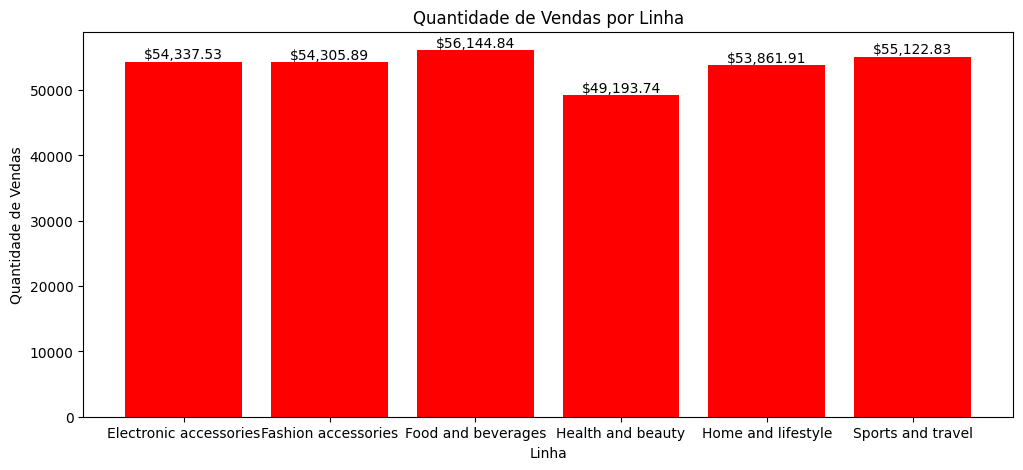

In [ ]:
plt.figure(figsize=(12,5))

for i, valor in enumerate(vendas_por_linha):
    plt.text(i, valor + 5, f'${valor:,.2f}', ha='center', va='bottom')

plt.bar(vendas_por_linha.index, vendas_por_linha, color='red')
plt.xlabel('Linha')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas por Linha')

plt.show()

A categoria "Food and Beverages" possui um volume de vendas significativamente maior, provavelmente devido à demanda constante e necessidade diária desses produtos. Já a categoria "Health and Beauty" apresenta vendas menores, possivelmente por ter ciclos de compra mais espaçados, preços mais altos e uma demanda mais específica. Apesar disso, pode ter margens de lucro mais altas e fidelização de clientes, já que muitos consumidores preferem marcas específicas para cuidados pessoais.

##Forma de Pagamento Por Cidade

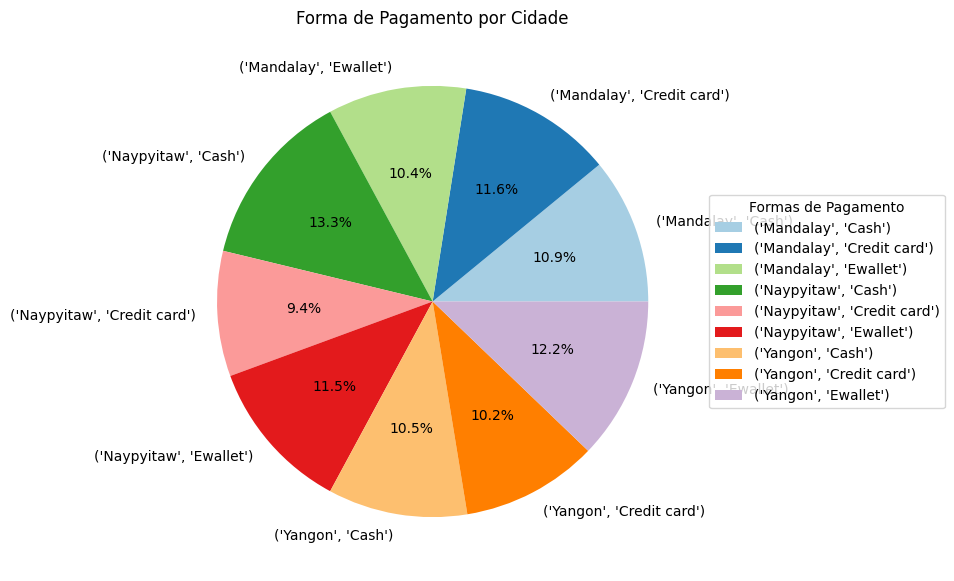

In [ ]:
plt.figure(figsize=(12, 7))

cores = plt.cm.Paired(range(len(forma_de_pagamento_cidade)))


plt.pie(forma_de_pagamento_cidade,
        labels=forma_de_pagamento_cidade.index,
        autopct='%1.1f%%',

        colors=cores,
        )

plt.title('Forma de Pagamento por Cidade')


plt.legend(forma_de_pagamento_cidade.index, title='Formas de Pagamento', loc='center left', bbox_to_anchor=(1, 0.5))



plt.show()

A distribuição das formas de pagamento entre as cidades é bastante equilibrada, refletindo uma tendência geral de aceitação das diferentes opções de pagamento. No entanto, é possível observar que o método "E-Wallet" tem números bastante próximos ao "Pagamento em Dinheiro", sugerindo que muitos consumidores preferem utilizar carteiras digitais, como uma alternativa prática e segura ao pagamento tradicional em dinheiro. Esse padrão pode ser impulsionado pelo aumento do uso de dispositivos móveis e a crescente confiança nas soluções digitais, especialmente em ambientes urbanos.

##Lucro Bruto acumulado

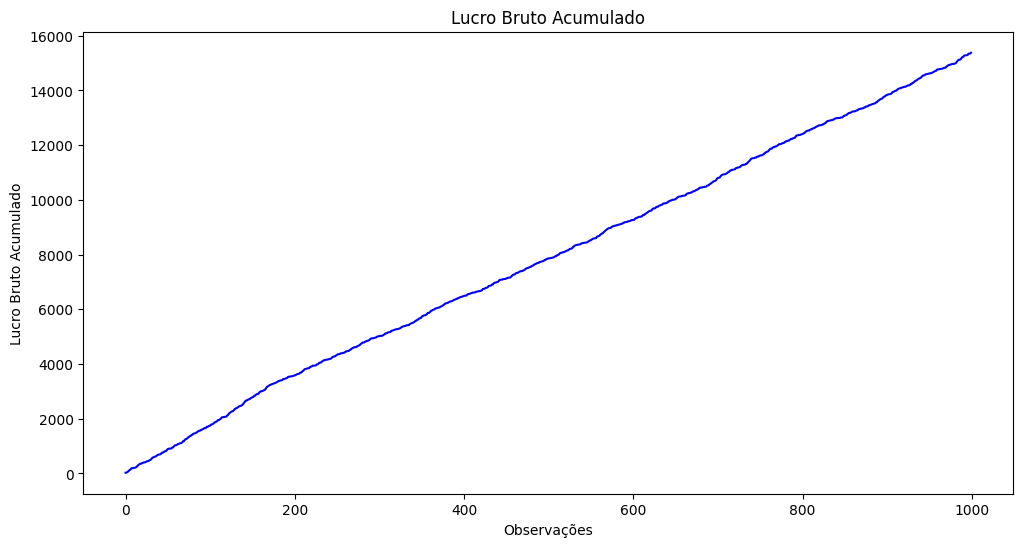

In [ ]:
df['Lucro Bruto Acumulado'] = df['Renda Bruta'].cumsum()
##retorna uma serie (ou array) aonde o elemento soma os valores anteriores mais o atual
plt.figure(figsize=(12, 6))
plt.plot(df['Lucro Bruto Acumulado'], color='blue')
plt.xlabel('Observações')
plt.ylabel('Lucro Bruto Acumulado')
plt.title('Lucro Bruto Acumulado')
plt.show()

In [ ]:
print(df.columns)

Index(['ID da Fatura', 'Filial', 'Cidade', 'Tipo de Cliente', 'Gênero',
       'Linha de Produto', 'Preço Unitário', 'Quantidade', 'Imposto 5%',
       'Total', 'Hora', 'Pagamento', 'Custo de Mercadorias Vendidas',
       'Percentual de Margem Bruta', 'Renda Bruta', 'Avaliação',
       'Lucro Bruto Acumulado'],
      dtype='object')


#Normalização / Padronização

In [ ]:
print(df.columns)

Index(['Preço Unitário', 'Quantidade', 'Total', 'Avaliação', 'Gênero'], dtype='object')


O código abaixo realiza a normalização e padronização de variáveis numéricas, garantindo que as variáveis fiquem dentro de uma mesma escala para facilitar a aplicação de modelos de aprendizado de máquina:

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Normalização (0 a 1)
scaler = MinMaxScaler()
# Removing the extra space in the column name 'Preço Unitário '
df['Preço Unitário'] = scaler.fit_transform(df[['Preço Unitário']])

# Padronização (média 0, desvio padrão 1)
scaler = StandardScaler()
df['Total'] = scaler.fit_transform(df[['Total']])



Para transformar variáveis categóricas em valores numéricos, foi aplicada a codificação utilizando diferentes técnicas, como maping, One-Hot Encoding e Label Encoding:

In [ ]:
df['Gênero'] = df['Gênero'].map({'Male': 0, 'Female': 1})
df['Tipo de Cliente'] = df['Tipo de Cliente'].map({'Member': 0, 'Normal': 1})
df['Pagamento'] = df['Pagamento'].map({'Cash': 0, 'Credit Card': 1, 'Ewallet':2})
#Codificando váriaveis



One-Hot Encoding (Cidade): A variável 'Cidade' foi codificada utilizando One-Hot Encoding, o que gera uma coluna binária para cada valor único na coluna original. A opção drop='first' foi utilizada para evitar a multicolinearidade, descartando a primeira coluna codificada.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_columns = encoder.fit_transform(df[['Cidade']])

# Adicionar as colunas ao DataFrame original
encoded_df = pd.DataFrame(encoded_columns, columns=encoder.get_feature_names_out(['Cidade']))
df = pd.concat([df, encoded_df], axis=1).drop('Cidade', axis=1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Codificando a coluna 'Linha de Produto' com valores numéricos
le = LabelEncoder()
df['Linha de Produto Codificada'] = le.fit_transform(df['Linha de Produto'])


NameError: name 'x' is not defined

# Modelagem

#Objetivo da Modelagem

O objetivo desta etapa é desenvolver modelos preditivos que possam estimar o valor de vendas (Total) com base nas variáveis independentes, como Preço Unitário, Quantidade, Avaliação, Gênero e Linha de Produto Codificada.

Para garantir que o modelo tenha um bom desempenho generalizando para novos dados, foi realizada a divisão do dataset em dois conjuntos: treinamento e teste.

In [ ]:
from sklearn.model_selection import train_test_split
X = df[['Preço Unitário', 'Quantidade', 'Avaliação', 'Gênero', 'Linha de Produto Codificada']]
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
print(y)

0       548.9715
1        80.2200
2       340.5255
3       489.0480
4       634.3785
         ...    
995      42.3675
996    1022.4900
997      33.4320
998      69.1110
999     649.2990
Name: Total, Length: 1000, dtype: float64


- A divisão de 70% dos dados para treinamento e 30% para teste é uma prática comum para garantir que o modelo tenha dados suficientes para aprender e também seja validado de forma independente em um conjunto de dados não visto.
- O parâmetro random_state=42 é utilizado para garantir a reprodutibilidade do processo de divisão, permitindo que os resultados sejam reproduzidos em diferentes execuções do código.

In [ ]:
# Mostra as dimensões do DataFrame após a codificação
print(f"Dimensões do DataFrame: {df.shape}")

# Mostra as primeiras linhas de X (variáveis independentes) e y (variável dependente)
X = df[['Preço Unitário', 'Quantidade', 'Avaliação', 'Gênero', 'Linha de Produto Codificada']]
print(f"X_train:\n{X_train.head()}")
print(f"y_train:\n{y_train.head()}")

Dimensões do DataFrame: (1000, 19)
X_train:
     Preço Unitário  Quantidade  Avaliação  Gênero  \
541           75.88           1        7.1    Male   
440           17.44           5        8.1    Male   
482           37.14           5        5.0    Male   
422           97.21          10        8.7  Female   
778           25.25           5        6.1    Male   

     Linha de Produto Codificada  
541                            3  
440                            2  
482                            5  
422                            1  
778                            5  
y_train:
541      79.6740
440      91.5600
482     194.9850
422    1020.7050
778     132.5625
Name: Total, dtype: float64


## Regressão Linear

A regressão linear foi escolhida por ser um dos modelos mais simples e amplamente utilizados para problemas de previsão, onde existe uma relação linear entre a variável dependente (Total) e as variáveis independentes (Preço Unitário, Quantidade, etc).

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(y_test, y_pred, "Regressão Linear")

521    523.9710
737    616.9800
740    408.7335
660    135.3555
411     45.9270
         ...   
468     22.6590
935    270.0180
428    353.1675
7      772.3800
155    484.5225
Name: Total, Length: 300, dtype: float64 [ 510.24073359  588.69762363  399.57962464   96.45977367  -78.85459466
  593.26365281  141.36423028  658.03532523  484.69919172  116.33396295
  499.34511607  476.07523052  253.57367158  322.56712091  400.38342512
  409.24163513  551.95595898  226.08970214  683.82176713  159.90005401
  410.49832891  248.09615144  159.09991134  142.47212941  353.17738468
  349.35616663  652.71549748 -107.19345309  141.4578938    56.74303049
  152.89333605  552.93396431  261.97920674  433.21978446  227.31282579
  145.68309278  633.90155105  217.88419808  182.97062006  193.43929525
  216.88926736  772.27128556   62.17914954  289.76738439  252.28038569
  469.266164    234.4310274   126.35152322  382.142863    290.50215931
  444.9563291   207.32657258   13.04334214  283.58700507  156.60232774
  

As métricas escolhidas para avaliar o modelo são:

  - Média dos Erros Absolutos (MAE): Mede a média das diferenças absolutas entre os valores previstos e os reais. Menores valores indicam que o modelo é mais preciso.
  - Média dos Quadrados dos Erros (MSE): Penaliza mais erros maiores, sendo útil para avaliar modelos que precisam minimizar grandes desvios nos resultados.

##Importando as Funções de Avaliação do Modelo de Regressão (Media Absoluta do Erro e Média Quadrática do Erro)  e Exibindo os valores da avalição

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
print("Média dos erros Absolutos" ,mean_absolute_error(y_test, y_pred_lr))
print("Média dos quadrados dos erros ",mean_squared_error(y_test, y_pred_lr))

Média dos erros Absolutos 62.25470660239292
Média dos quadrados dos erros  6870.345048875977


#Árvore de Decisão

A Árvore de Decisão foi escolhida por ser um modelo não-linear que pode capturar interações complexas entre as variáveis. Além disso, ele é mais flexível que a regressão linear, já que pode modelar relações não-lineares e interações entre as variáveis independentes.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Média dos erros Absolutos" ,mean_absolute_error(y_test, y_pred_dt))
print("Média dos quadrados dos erros ",mean_squared_error(y_test, y_pred_dt))

Média dos erros Absolutos 8.112440000000001
Média dos quadrados dos erros  197.08021136999997


A Média dos Erros Absolutos (62.25) indica uma boa previsão, com o modelo sendo capaz de capturar variações significativas nos dados.

#Avaliação Cruzada

A avaliação cruzada é uma técnica importante para avaliar o desempenho de um modelo de maneira robusta, utilizando diferentes subconjuntos dos dados de treinamento para treinar e testar o modelo várias vezes.

In [ ]:
from sklearn.model_selection import cross_val_score

model = LinearRegression()
cross_val_score(model, X, y, cv=15)

array([0.89490815, 0.90339819, 0.90638354, 0.87861569, 0.82647646,
       0.86922889, 0.87635824, 0.84751929, 0.89709439, 0.87522636,
       0.91480506, 0.91009197, 0.83332468, 0.90112582, 0.89574855])

A média das pontuações R² variou entre 0.82 e 0.91, com a maioria dos valores próximos de 0.90. Isso mostra que o modelo é robusto e consegue explicar bem a variabilidade dos dados, com destaque para a consistência dos resultados.

#Conclusão

- O modelo de regressão linear tem uma boa performance, mas a árvore de decisão parece ter um desempenho superior, com menor erro médio absoluto.
- O R² da validação cruzada é bastante sólido, sugerindo que o modelo é confiável para as previsões. Considerando isso, a árvore de decisão pode ser mais adequada se houver complexidade nos dados, enquanto a regressão linear oferece uma boa base inicial.

